In [1]:
# Etapa 3 — Machine Learning
# Rode a partir de notebooks/ e só depois da Etapa 2 ter salvo dataset.csv.

# Etapa 3 — Machine Learning

Rode **a partir de `notebooks/`**, depois da Etapa 2 ter salvo
`data/processed/dataset.csv`.

Vamos treinar um classificador que rotula cada hora como **RUIM**,
**BOM** ou **ÓTIMO** para surfar.

Plano:
1. Carregar `data/processed/dataset.csv` (gerado na Etapa 2).
2. Criar a label **`surfavel`** com regras heurísticas.
3. Preparar X e y (features numéricas + categóricas).
4. `train_test_split`.
5. Treinar 3 modelos do `sklearn`:
   - `DecisionTreeClassifier`
   - `RandomForestClassifier`
   - `KNeighborsClassifier`
6. Avaliar com `classification_report`, matriz de confusão, cross-val.
7. Plotar a árvore de decisão e a importância das features.
8. Aplicar o melhor modelo no dataset inteiro e responder:
   **quando Felipe e Nicholas devem voltar a João Pessoa?**

O modelo só ranqueia a janela de previsão (~6–7 dias). Não responde
"qual o melhor mês do ano" — isso está em `docs/projeto.md`.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

DIR_PROC = Path("../data/processed")

## 1. Carregar o dataset processado

In [3]:
df = pd.read_csv(DIR_PROC / "dataset.csv", parse_dates=["datahora", "data"])
print("shape:", df.shape)
df.head()

shape: (144, 12)


,datahora,data,hora,altura_onda_m,direcao_onda,vento_kmh,direcao_vento,altura_mare_m,mare_subindo,coeficiente,dia_semana,periodo_dia
0,2026-06-05 00:00:00,2026-06-05,0,1.3,ESE,17.0,S,0.869811,False,53,Friday,madrugada
1,2026-06-05 01:00:00,2026-06-05,1,1.3,ESE,17.0,S,0.756757,False,53,Friday,madrugada
2,2026-06-05 02:00:00,2026-06-05,2,1.3,ESE,16.0,S,0.983784,True,53,Friday,madrugada
3,2026-06-05 03:00:00,2026-06-05,3,1.3,ESE,16.0,S,1.210811,True,53,Friday,madrugada
4,2026-06-05 04:00:00,2026-06-05,4,1.3,ESE,17.0,S,1.437838,True,53,Friday,madrugada


## 2. Criar a label `surfavel`

**Heuristica usada (limiares discutidos para o litoral de Joao Pessoa):**

- `RUIM`  -> vento >= 22 km/h **ou** altura < 0.7 m
- `OTIMO` -> altura >= 1.0 m **e** vento < 18 km/h **e** mare subindo
- `BOM`   -> o resto

A logica e:
- vento forte na costa estraga qualquer onda (mata o swell);
- onda muito pequena nao quebra direito;
- mare subindo costuma deixar a onda mais formada nas praias da regiao.

Os limiares sao chutes informados — em um projeto real virariam de
entrevistas com surfistas e comparacao com previsoes profissionais.

In [4]:
def classificar(row: pd.Series) -> str:
    if row["vento_kmh"] >= 22 or row["altura_onda_m"] < 0.7:
        return "RUIM"
    if (row["altura_onda_m"] >= 1.0
        and row["vento_kmh"] < 18
        and row["mare_subindo"]):
        return "OTIMO"
    return "BOM"

df["surfavel"] = df.apply(classificar, axis=1)
print(df["surfavel"].value_counts())

surfavel
BOM      73
OTIMO    43
RUIM     28
Name: count, dtype: int64


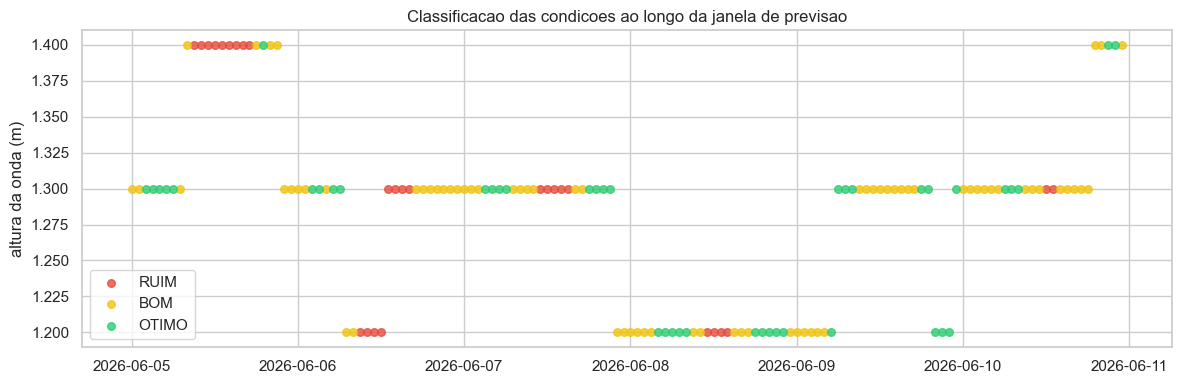

In [5]:
# Visualizar a distribuicao das classes ao longo do tempo
fig, ax = plt.subplots(figsize=(12, 4))
cores = {"RUIM": "#e74c3c", "BOM": "#f1c40f", "OTIMO": "#2ecc71"}
for classe in ["RUIM", "BOM", "OTIMO"]:
    sub = df[df["surfavel"] == classe]
    ax.scatter(sub["datahora"], sub["altura_onda_m"],
               c=cores[classe], label=classe, s=30, alpha=0.8)
ax.set_title("Classificacao das condicoes ao longo da janela de previsao")
ax.set_ylabel("altura da onda (m)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Preparar X e y

Usamos features numericas e algumas categoricas (one-hot).

In [6]:
features_num = ["altura_onda_m", "vento_kmh", "altura_mare_m", "coeficiente", "hora"]
features_cat = ["direcao_onda", "direcao_vento", "periodo_dia", "mare_subindo"]

X = pd.get_dummies(df[features_num + features_cat], columns=features_cat, drop_first=False)
y = df["surfavel"]

print("X shape:", X.shape)
print("colunas:", list(X.columns))

X shape: (144, 18)
colunas: ['altura_onda_m', 'vento_kmh', 'altura_mare_m', 'coeficiente', 'hora', 'direcao_onda_E', 'direcao_onda_ESE', 'direcao_vento_ESE', 'direcao_vento_S', 'direcao_vento_SE', 'direcao_vento_SSE', 'direcao_vento_SSW', 'periodo_dia_madrugada', 'periodo_dia_manha', 'periodo_dia_noite', 'periodo_dia_tarde', 'mare_subindo_False', 'mare_subindo_True']


## 4. Dividir treino e teste (80/20)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("treino:", X_train.shape, "teste:", X_test.shape)

treino: (115, 18) teste: (29, 18)


## 5. Treinar os 3 modelos

In [8]:
modelos = {
    "DecisionTree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    cv = cross_val_score(modelo, X, y, cv=5).mean()
    resultados[nome] = {"acc_teste": acc, "cv5_media": cv}
    print(f"{nome:14s} acc_teste={acc:.3f}  cv5_media={cv:.3f}")

DecisionTree   acc_teste=1.000  cv5_media=1.000


RandomForest   acc_teste=0.966  cv5_media=0.986
KNN            acc_teste=0.690  cv5_media=0.756


In [9]:
# Tabela comparativa
pd.DataFrame(resultados).T

,acc_teste,cv5_media
DecisionTree,1.000000,1.000000
RandomForest,0.965517,0.985714
KNN,0.689655,0.756404


## 6. Avaliacao detalhada

Olhamos o melhor modelo (maior `cv5_media`) com mais cuidado.

In [10]:
melhor_nome = max(resultados, key=lambda n: resultados[n]["cv5_media"])
melhor = modelos[melhor_nome]
print(f"melhor modelo: {melhor_nome}\n")

pred = melhor.predict(X_test)
print(classification_report(y_test, pred))

melhor modelo: DecisionTree

              precision    recall  f1-score   support

         BOM       1.00      1.00      1.00        15
       OTIMO       1.00      1.00      1.00         9
        RUIM       1.00      1.00      1.00         5

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



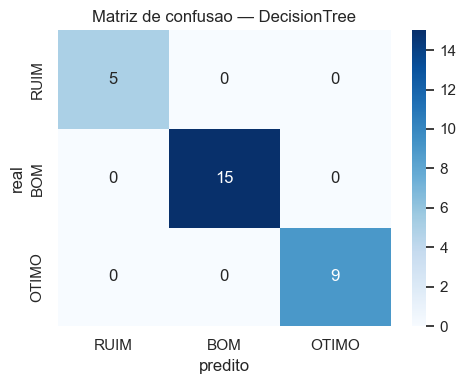

In [11]:
# Matriz de confusao
labels = ["RUIM", "BOM", "OTIMO"]
cm = confusion_matrix(y_test, pred, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("predito")
ax.set_ylabel("real")
ax.set_title(f"Matriz de confusao — {melhor_nome}")
plt.tight_layout()
plt.show()

## 7. Visualizando o que o modelo aprendeu

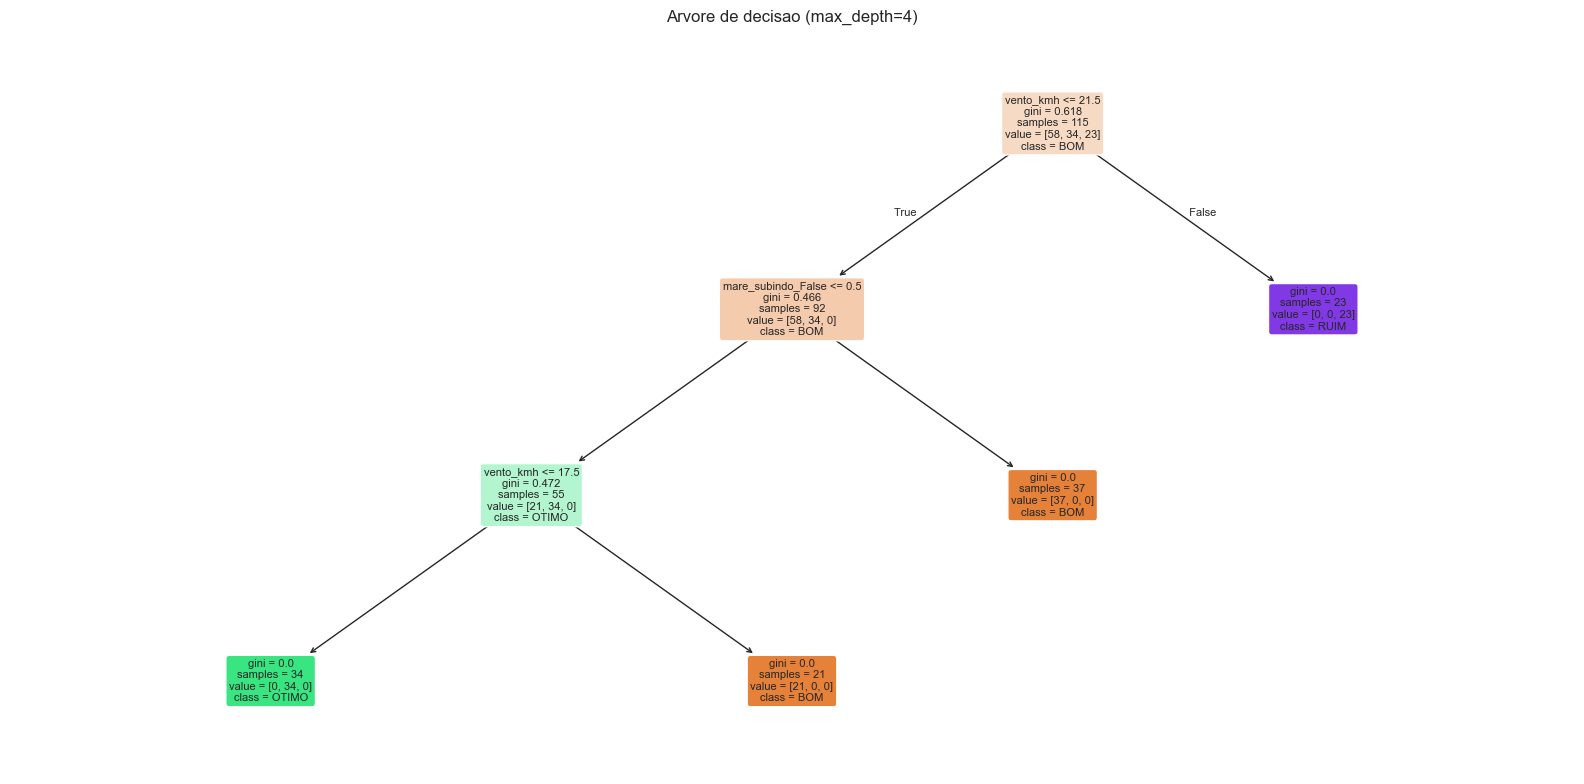

In [12]:
# 7.1 Plotar a arvore de decisao (ela e interpretavel)
arvore = modelos["DecisionTree"]
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(arvore, feature_names=X.columns, class_names=arvore.classes_,
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title("Arvore de decisao (max_depth=4)")
plt.tight_layout()
plt.show()

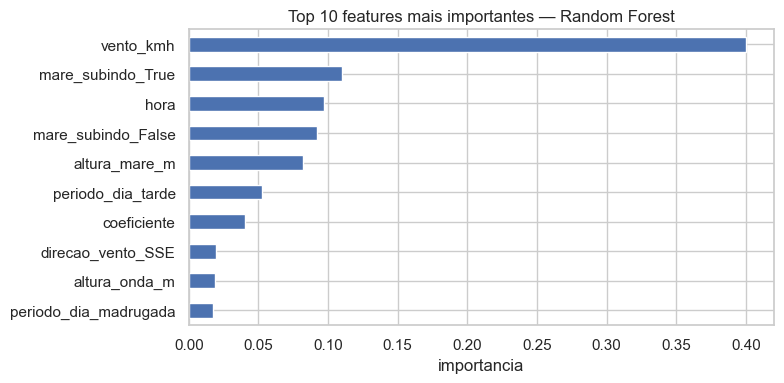

In [13]:
# 7.2 Importancia das features na Random Forest
rf = modelos["RandomForest"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8, 4))
imp.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("Top 10 features mais importantes — Random Forest")
ax.set_xlabel("importancia")
plt.tight_layout()
plt.show()

## 8. Aplicar no dataset inteiro e responder a pergunta

O modelo aprendeu uma regra que, em principio, deveria recuperar a
heuristica original. O interessante e usar o classificador para
**rankear dias e horarios** dentro da janela de previsao.

In [14]:
df["pred"] = melhor.predict(X)
df["pred_otimo"] = (df["pred"] == "OTIMO").astype(int)
df["pred_pelomenos_bom"] = df["pred"].isin(["BOM", "OTIMO"]).astype(int)

In [15]:
# 8.1 Top dias da janela (mais horas otimas)
ranking_dia = (df.groupby("data")
                 .agg(horas_otimas=("pred_otimo", "sum"),
                      horas_pelomenos_bom=("pred_pelomenos_bom", "sum"))
                 .sort_values(["horas_otimas", "horas_pelomenos_bom"], ascending=False))
print("Top dias:")
print(ranking_dia)

Top dias:
            horas_otimas  horas_pelomenos_bom
data                                         
2026-06-09            10                   24
2026-06-08            10                   20
2026-06-07             8                   19
2026-06-05             6                   15
2026-06-10             5                   22
2026-06-06             4                   16


In [16]:
# 8.2 Melhor horario do dia (em media, na janela)
melhor_hora = (df.assign(eh_otimo=df["pred_otimo"])
                 .groupby("hora")["eh_otimo"]
                 .mean()
                 .sort_values(ascending=False))
print("\nProporcao de horas OTIMAS por hora do dia:")
print(melhor_hora.head(10))


Proporcao de horas OTIMAS por hora do dia:
hora
6     1.000000
5     0.833333
21    0.666667
19    0.666667
3     0.500000
4     0.500000
7     0.500000
8     0.500000
22    0.500000
20    0.500000
Name: eh_otimo, dtype: float64


In [17]:
# 8.3 Salvar o dataset rotulado
saida = DIR_PROC / "dataset_rotulado.csv"
df.to_csv(saida, index=False)
print(f"\nsalvo: {saida}")


salvo: ../data/processed/dataset_rotulado.csv


## 9. Conclusao para Felipe e Nicholas

A partir do classificador aplicado a janela de previsao disponivel
no site:

- O **dia com mais horas otimas** e o que aparece no topo do ranking acima.
- O **horario mais provavel de pegar onda boa** e o que aparece no topo
  do ranking horario (`melhor_hora`).

**Limitacoes importantes** (parte do exercicio: comunica-las):

1. O site so disponibiliza ~6-7 dias de previsao de onda/vento. Nao da
   para responder honestamente "qual o melhor mes do ano" sem coletar
   dados ao longo do tempo.
2. Nossa heuristica e simples: nao considera periodo de swell (o site
   nao expoe isso) nem direcao da onda relativa a praia especifica.
3. O classificador aprende a reproduzir a heuristica — ele e tao bom
   quanto ela. Para um modelo de surf de verdade precisariamos de labels
   de surfistas reais.

Para uma versao "ano completo" da analise, o caminho seria rodar o
scraper diariamente por algumas semanas/meses e acumular historico —
isso fica como sugestao para um proximo projeto.